In [397]:
from math import tanh
class Value:
    def __init__(self, data, _children =(), _op =''):
        self.data = data
        self.grad = 0
        self._op=_op
        self._prev = _children
        self._backward = lambda : None

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad*other.data
            other.grad += out.grad*self.data
        out._backward = _backward
        return out
    
    def tanh(self):
        out = Value(tanh(self.data), (self,), 'tanh')
        def _backward():
            self.grad += ( 1- tanh(self.data)**2 )* out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        node_order = []

        def build(root):
            if root not in node_order:
                if root._prev:
                    for node in root._prev:
                        build(node)
                node_order.append(root)
                
        build(self)
        self.grad=1.0
        for node in reversed(node_order):
            node._backward()
                
    def __neg__(self):
        return self * -1
    
    def __sub__(self, x):
        return self + -x
    
    def __pow__(self, other):
        out = Value(self.data ** other, (self,), '**')
        def _backward():
            self.grad += other * self.data**(other-1) * out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other
        

        

In [398]:
a = Value(0.5)
b = Value(0.8)
c = a + b
d = c * a
e = d.tanh()
d

In [399]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label=f"data {n.data:.4f} | grad {n.grad:.4f}",
            shape="record"
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

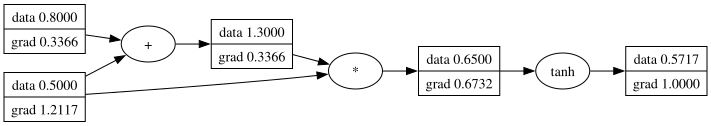

In [400]:
e.backward()
draw_dot(e)


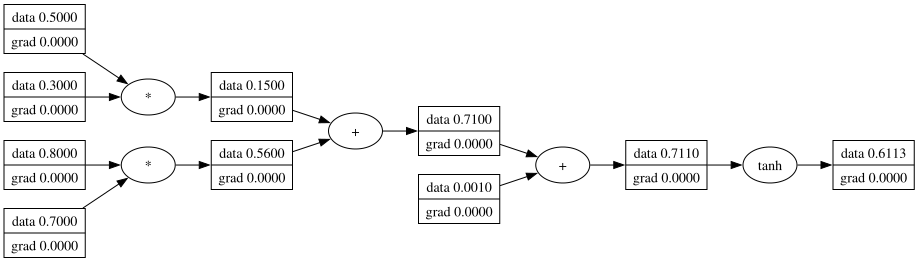

In [401]:
w1, w2 = Value(0.3), Value(0.8)
x1, x2 = Value(0.5), Value(0.7)
b = Value(0.001)
w1x1 = w1*x1
w2x2 = w2*x2
h = w1x1 + w2x2 + b
o = h.tanh()
draw_dot(o)



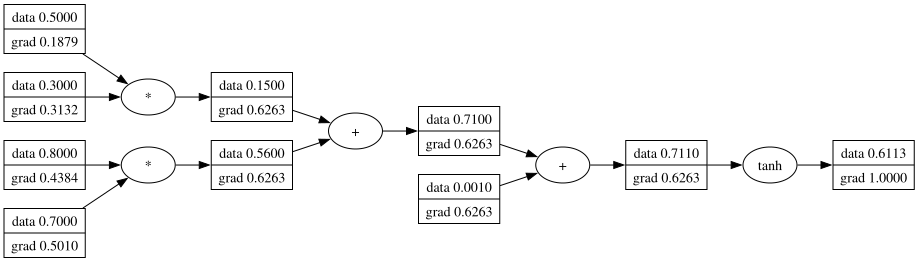

In [402]:
o.backward()
draw_dot(o)

In [403]:
import random
class Neuron:
    def __init__(self, nin):
        self.weights = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0.001)

    def __call__(self, x):
        activation = sum((w1*x1 for w1, x1 in zip(self.weights, x)) ,self.b)
        return activation.tanh()
    
    def parameters(self):
        return self.weights + [self.b]
    


In [404]:
class Layer:
    def __init__(self, nin, nout):
        self.layer = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outputs = []
        for neuron in self.layer:
            outputs.append(neuron(x))
        if len(outputs)==1:
            return outputs[0]
        return outputs

    def parameters(self):
        flatten_arr = []
        for neuron in self.layer:
            flatten_arr.extend(neuron.parameters())
        return flatten_arr

In [405]:
class MLP:
    def __init__(self, lin, lout):
        arr = [lin,]
        arr.extend(lout)
        self.layers = []
        for x in range(len(arr)-1):
            self.layers.append(Layer(arr[x], arr[x+1]))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params

In [406]:
model = MLP(2, [4, 4, 1])
x = [Value(0.5), Value(0.7)]
ypred = model(x)
ypred

In [407]:
ypred.backward()

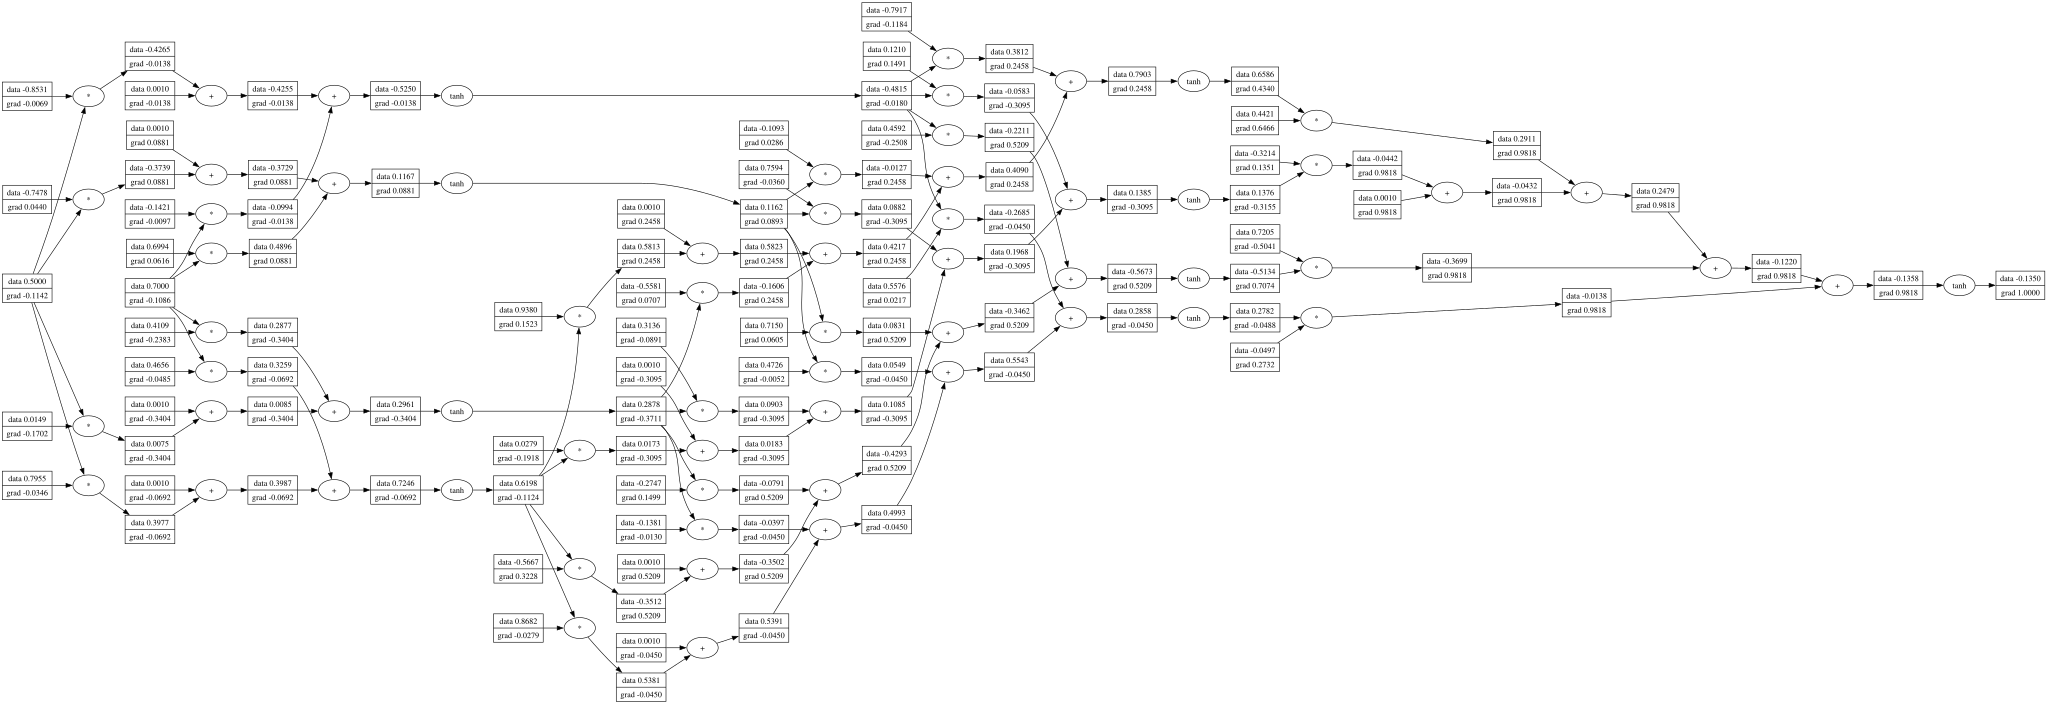

In [408]:
draw_dot(ypred)

In [409]:
a = Value(3)
b = Value(2)
loss = (a - b) ** 2
loss.backward()

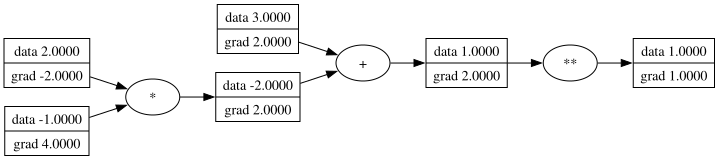

In [410]:
draw_dot(loss)

In [411]:
xs = [
    [2.0, 3.0],
    [3.0, -1.0],
    [0.5, 1.0],
    [1.0, 1.0],
]

ys = [1.0, -1.0, 1.0, -1.0]

model = MLP(2, [4, 4, 1])

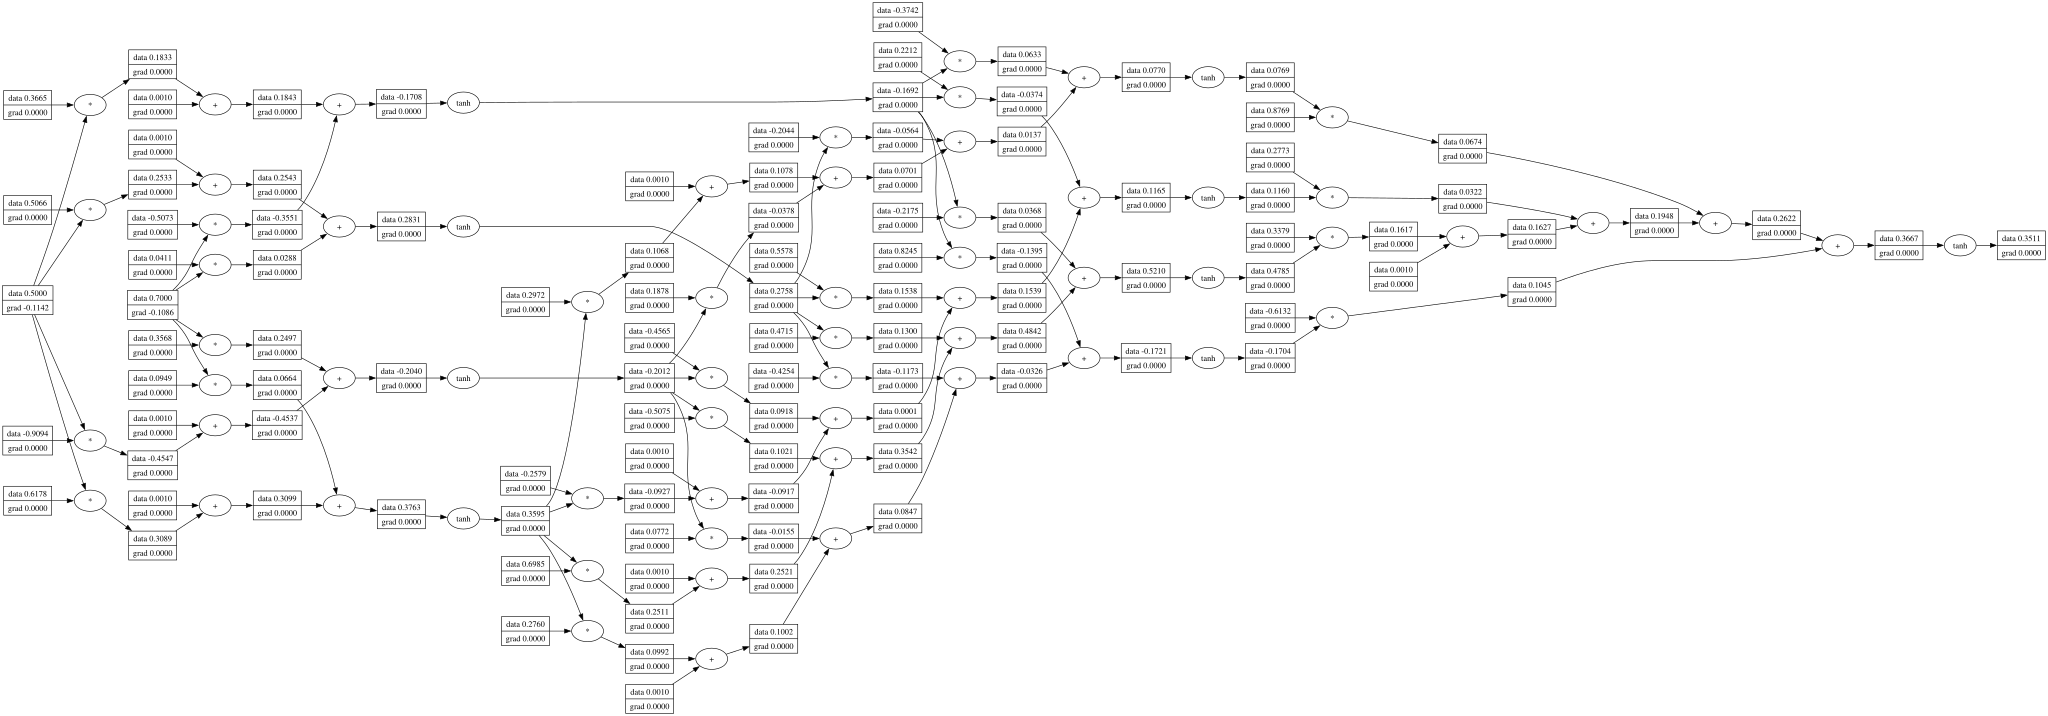

In [412]:
prediction = model(x)
draw_dot(prediction)

In [413]:
for k in range(100):

    # forward pass
    ypred = [model(x) for x in xs]

    # loss
    loss = sum((yout - ygt) ** 2 for yout, ygt in zip(ypred, ys))

    # zero gradients
    for p in model.parameters():
        p.grad = 0

    # backward pass
    loss.backward()

    # update
    learning_rate = 0.05
    for p in model.parameters():
        p.data += -learning_rate * p.grad

    print(k, loss.data)

0 3.176816312997592
1 2.4932232761356365
2 2.723698232394476
3 1.8520044175232098
4 1.6886146327081404
5 1.5581446407096409
6 1.5941707761286188
7 2.0619760866781798
8 3.432570663782351
9 2.9725811248412133
10 1.8118746461846593
11 1.5566874021656143
12 2.1381896385742447
13 1.2282074771923424
14 1.7140812839941886
15 1.7389465319980535
16 3.1291071314035004
17 1.9962168901428563
18 1.0433456521606672
19 1.2891332663921542
20 1.4917924213336418
21 2.6521441439254607
22 0.5911492664010117
23 0.5401345913852877
24 0.49904722716028477
25 0.4837728991933932
26 0.45769911806930097
27 0.461089481356867
28 0.4331519498755084
29 0.4314492353923257
30 0.38024838766604985
31 0.33333853744667585
32 0.22432970380946038
33 0.15384446363821272
34 0.11871867232655345
35 0.1093562418983986
36 0.10222902923926297
37 0.09587711971450755
38 0.0901604963054746
39 0.08499552748846062
40 0.08031213735387613
41 0.07605098234561289
42 0.07216156528698842
43 0.06860071752557534
44 0.06533137128375525
45 0.0623

In [414]:
xs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
]

ys = [0.0, 1.0, 1.0, 0.0]
model = MLP(2, [ 4, 1])

for k in range(200):

    # predictions
    ypred = [model(x) for x in xs]

    # loss
    loss = sum((pred - ygt)**2 for pred, ygt in zip(ypred, ys))

    # zero gradients
    for p in model.parameters():
        p.grad = 0

    # backward
    loss.backward()

    # update
    lr = 0.1
    for p in model.parameters():
        p.data += -lr * p.grad

    if k % 10 == 0:
        print(k, loss.data)

0 1.3847073702848958
10 0.8138476694314029
20 0.6044607661666903
30 0.37490580320214634
40 0.20445281367486937
50 0.4290627936972416
60 0.25495380740338586
70 0.16029822328537438
80 0.108716692983964
90 0.08063629766964237
100 0.06482986832884213
110 0.055621796966381726
120 0.05009258119461513
130 0.04662265290794933
140 0.0442525545359093
150 0.042415086493506525
160 0.04080505871101748
170 0.03928742565103552
180 0.037822223415415024
190 0.036411045091250274


In [415]:
xs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
]

ys = [0.0, 1.0, 1.0, 0.0]
model = MLP(2, [ 3, 4, 1])

for k in range(200):

    # predictions
    ypred = [model(x) for x in xs]

    # loss
    loss = sum((pred - ygt)**2 for pred, ygt in zip(ypred, ys))

    # zero gradients
    for p in model.parameters():
        p.grad = 0

    # backward
    loss.backward()

    # update
    lr = 0.1
    for p in model.parameters():
        p.data += -lr * p.grad

    if k % 10 == 0:
        print(k, loss.data)

0 4.138317606096063
10 0.8977503148412506
20 0.7456882237680682
30 0.5931943776698141
40 0.38931803862882475
50 0.1825115047102316
60 0.08181833196046066
70 0.3281298280515586
80 0.0686236257544905
90 0.07337328670287536
100 0.021442995893343673
110 0.0147286633481395
120 0.01509608064988361
130 0.018216898965413078
140 0.01608619589957988
150 0.011816454939436095
160 0.009381046225217533
170 0.008405325044598644
180 0.008196622822828136
190 0.008154154775516724
